In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
#opening data
import os
import pathlib
import warnings
#used for plots
from mplsoccer import Pitch
from scipy.stats import binned_statistic_2d

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [2]:
df = pd.DataFrame()
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/events_England.json')
with open(path) as f:
    data = json.load(f)
df = pd.concat([df, pd.DataFrame(data)], ignore_index = True)
df

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175
...,...,...,...,...,...,...,...,...,...,...,...,...
643145,5,Ball out of the field,[],0,"[{'y': 32, 'x': 0}, {'y': 100, 'x': 100}]",2500098,Interruption,1623,2H,2796.732525,50,251596409
643146,3,Corner,"[{'id': 302}, {'id': 801}, {'id': 1801}]",70965,"[{'y': 100, 'x': 100}, {'y': 47, 'x': 88}]",2500098,Free Kick,1633,2H,2829.821084,30,251596232
643147,1,Air duel,"[{'id': 701}, {'id': 1802}]",7919,"[{'y': 53, 'x': 12}, {'y': 50, 'x': 14}]",2500098,Duel,1623,2H,2831.211419,10,251596410
643148,1,Air duel,"[{'id': 703}, {'id': 1801}]",8005,"[{'y': 47, 'x': 88}, {'y': 50, 'x': 86}]",2500098,Duel,1633,2H,2832.434399,10,251596234


In [3]:
next_event = df.shift(-1, fill_value=0)
df["nextEvent"] = next_event["subEventName"]

df["kickedOut"] = df.apply(lambda x: 1 if x.nextEvent == "Ball out of the field" else 0, axis = 1)
#get move_df
move_df = df.loc[df['subEventName'].isin(['Simple pass', 'High pass', 'Head pass', 'Smart pass', 'Cross'])]
#filtering out of the field
delete_passes = move_df.loc[move_df["kickedOut"] == 1]
move_df = move_df.drop(delete_passes.index)

#extract coordinates
move_df["x"] = move_df.positions.apply(lambda cell: (cell[0]['x']) * 105/100)
move_df["y"] = move_df.positions.apply(lambda cell: (100 - cell[0]['y']) * 68/100)
move_df["end_x"] = move_df.positions.apply(lambda cell: (cell[1]['x']) * 105/100)
move_df["end_y"] = move_df.positions.apply(lambda cell: (100 - cell[1]['y']) * 68/100)
move_df = move_df.loc[(((move_df["end_x"] != 0) & (move_df["end_y"] != 68)) & ((move_df["end_x"] != 105) & (move_df["end_y"] != 0)))]
move_df

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,nextEvent,kickedOut,x,y,end_x,end_y
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171,High pass,0,51.45,34.68,32.55,14.96
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172,Head pass,0,32.55,14.96,53.55,17.00
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173,Head pass,0,53.55,17.00,36.75,19.72
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174,Simple pass,0,36.75,19.72,43.05,3.40
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175,Simple pass,0,43.05,3.40,75.60,8.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643133,8,Simple pass,[{'id': 1801}],37725,"[{'y': 56, 'x': 57}, {'y': 63, 'x': 65}]",2500098,Pass,1633,2H,2758.973892,85,251596217,Simple pass,0,59.85,29.92,68.25,25.16
643134,8,Simple pass,[{'id': 1801}],8313,"[{'y': 63, 'x': 65}, {'y': 96, 'x': 61}]",2500098,Pass,1633,2H,2760.286946,85,251596219,Simple pass,0,68.25,25.16,64.05,2.72
643135,8,Simple pass,[{'id': 1801}],379209,"[{'y': 96, 'x': 61}, {'y': 85, 'x': 40}]",2500098,Pass,1633,2H,2763.698599,85,251596221,Touch,0,64.05,2.72,42.00,10.20
643141,8,Simple pass,[{'id': 1801}],8561,"[{'y': 70, 'x': 59}, {'y': 89, 'x': 53}]",2500098,Pass,1633,2H,2783.137836,85,251596225,High pass,0,61.95,20.40,55.65,7.48


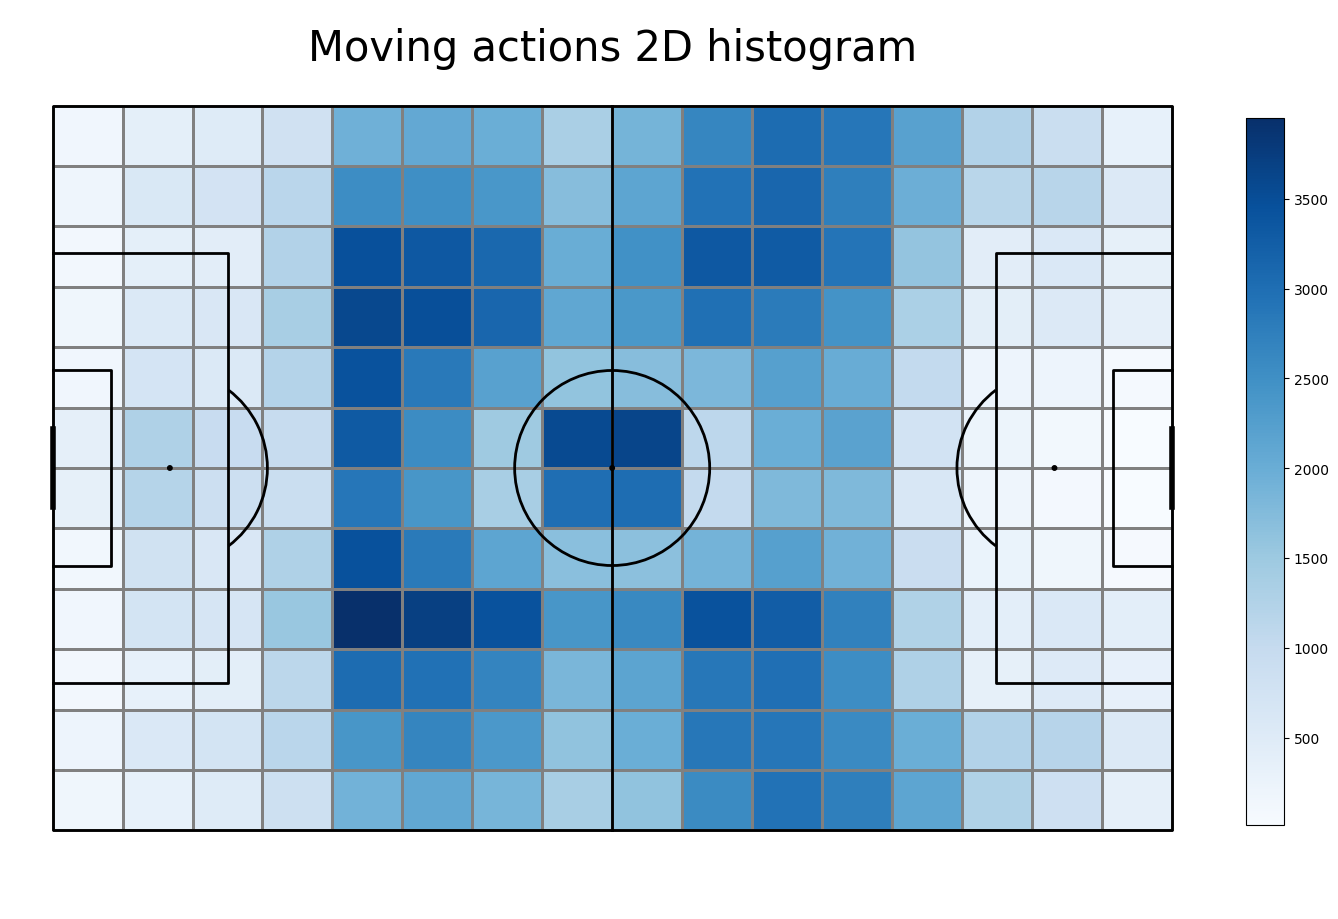

In [4]:
#create 2D histogram of these
pitch = Pitch(line_color='black',pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
move = pitch.bin_statistic(move_df.x, move_df.y, statistic='count', bins=(16, 12), normalize=False)

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pcm  = pitch.heatmap(move, cmap='Blues', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Moving actions 2D histogram', fontsize = 30)
plt.show()

In [5]:
#get shot df
shot_df = df.loc[df['subEventName'] == "Shot"]
shot_df["x"] = shot_df.positions.apply(lambda cell: (cell[0]['x']) * 105/100)
shot_df["y"] = shot_df.positions.apply(lambda cell: (100 - cell[0]['y']) * 68/100)
shot_df

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,nextEvent,kickedOut,x,y
46,10,Shot,"[{'id': 101}, {'id': 402}, {'id': 201}, {'id':...",25413,"[{'y': 41, 'x': 88}, {'y': 0, 'x': 0}]",2499719,Shot,1609,1H,94.595788,100,177959212,Reflexes,0,92.40,40.12
62,10,Shot,"[{'id': 401}, {'id': 201}, {'id': 1211}, {'id'...",26150,"[{'y': 52, 'x': 85}, {'y': 100, 'x': 100}]",2499719,Shot,1631,1H,179.854785,100,177959247,Ball out of the field,1,89.25,32.64
91,10,Shot,"[{'id': 101}, {'id': 403}, {'id': 201}, {'id':...",14763,"[{'y': 52, 'x': 96}, {'y': 100, 'x': 100}]",2499719,Shot,1631,1H,254.745027,100,177959280,Reflexes,0,100.80,32.64
128,10,Shot,"[{'id': 401}, {'id': 201}, {'id': 1215}, {'id'...",7868,"[{'y': 33, 'x': 81}, {'y': 0, 'x': 0}]",2499719,Shot,1609,1H,425.824035,100,177959289,Ball out of the field,1,85.05,45.56
249,10,Shot,"[{'id': 402}, {'id': 201}, {'id': 1205}, {'id'...",7868,"[{'y': 30, 'x': 75}, {'y': 0, 'x': 0}]",2499719,Shot,1609,1H,815.462015,100,177959429,Save attempt,0,78.75,47.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642945,10,Shot,"[{'id': 401}, {'id': 1212}, {'id': 1802}]",8561,"[{'y': 45, 'x': 72}, {'y': 0, 'x': 0}]",2500098,Shot,1633,2H,1972.969422,100,251596053,Ball out of the field,1,75.60,37.40
643023,10,Shot,"[{'id': 101}, {'id': 402}, {'id': 201}, {'id':...",41174,"[{'y': 33, 'x': 86}, {'y': 0, 'x': 0}]",2500098,Shot,1633,2H,2193.887080,100,251596096,Reflexes,0,90.30,45.56
643051,10,Shot,"[{'id': 402}, {'id': 201}, {'id': 1201}, {'id'...",7879,"[{'y': 62, 'x': 88}, {'y': 100, 'x': 100}]",2500098,Shot,1623,2H,2377.197700,100,251596357,Reflexes,0,92.40,25.84
643055,10,Shot,"[{'id': 402}, {'id': 201}, {'id': 1206}, {'id'...",145692,"[{'y': 38, 'x': 92}, {'y': 100, 'x': 100}]",2500098,Shot,1623,2H,2381.481625,100,251596359,Reflexes,0,96.60,42.16


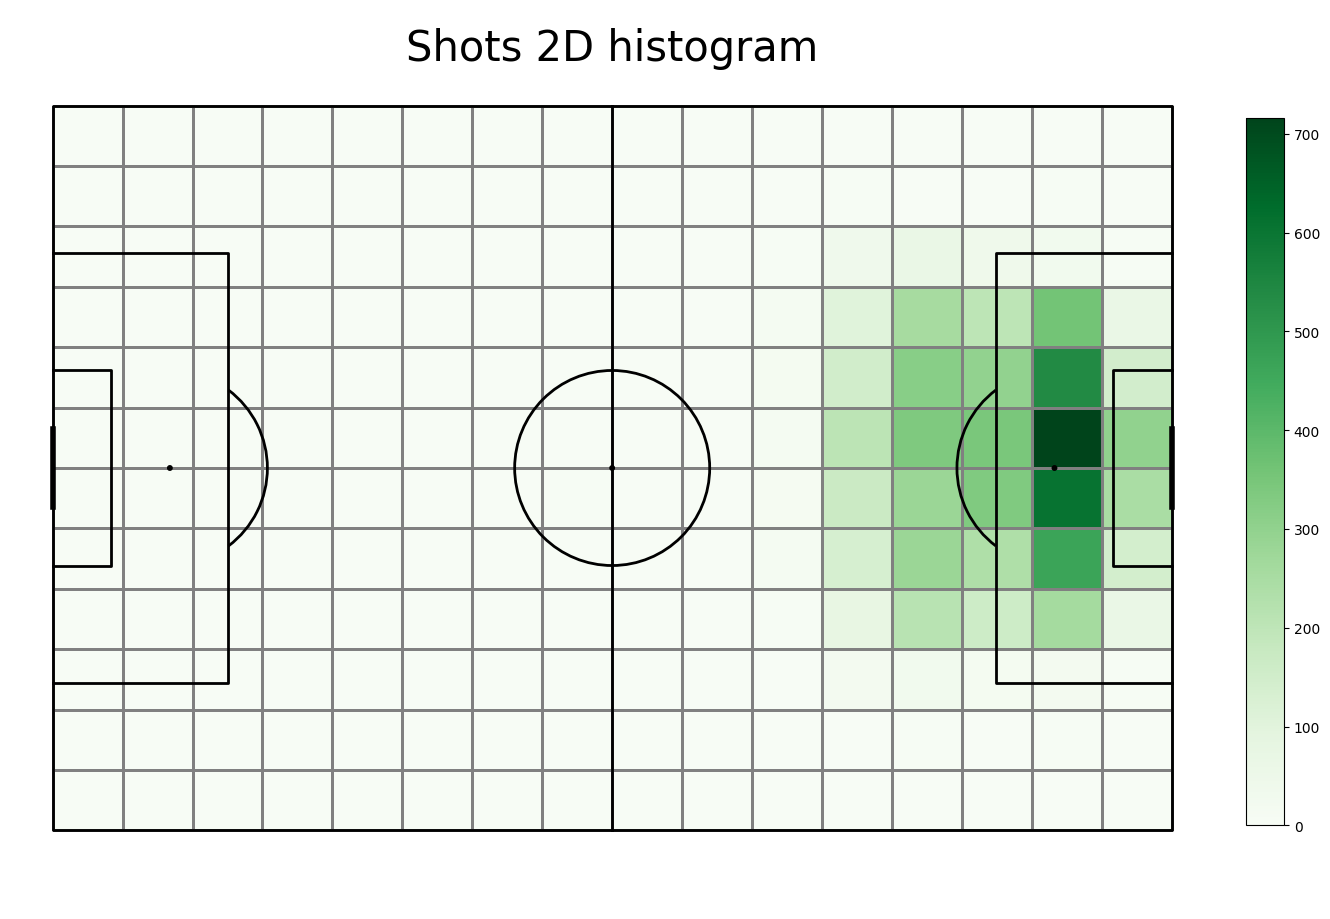

In [6]:
#create 2D histogram of these
shot = pitch.bin_statistic(shot_df.x, shot_df.y, statistic='count', bins=(16, 12), normalize=False)

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pcm  = pitch.heatmap(shot, cmap='Greens', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Shots 2D histogram', fontsize = 30)
plt.show()

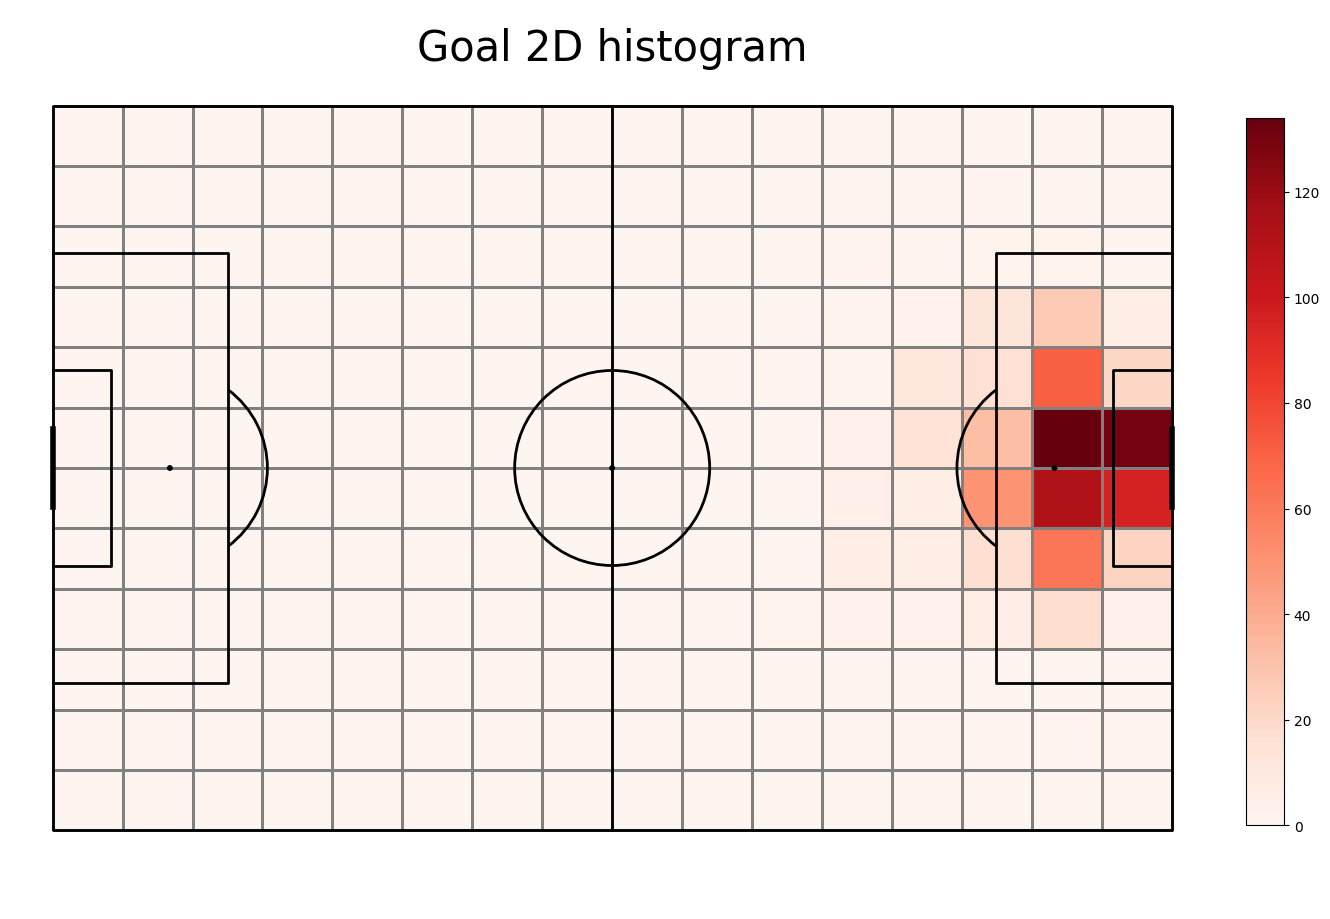

In [7]:
#get goal df
goal_df  = shot_df.loc[shot_df.apply(lambda x: {'id':101} in x.tags, axis = 1)]
goal = pitch.bin_statistic(goal_df.x, goal_df.y, statistic='count', bins=(16, 12), normalize=False)
goal_count = goal["statistic"]

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pcm  = pitch.heatmap(goal, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Goal 2D histogram', fontsize = 30)
plt.show()

In [8]:
move_count = move["statistic"]
shot_count = shot["statistic"]
move_probability = move_count/(move_count+shot_count)
move_probability.shape

(12, 16)

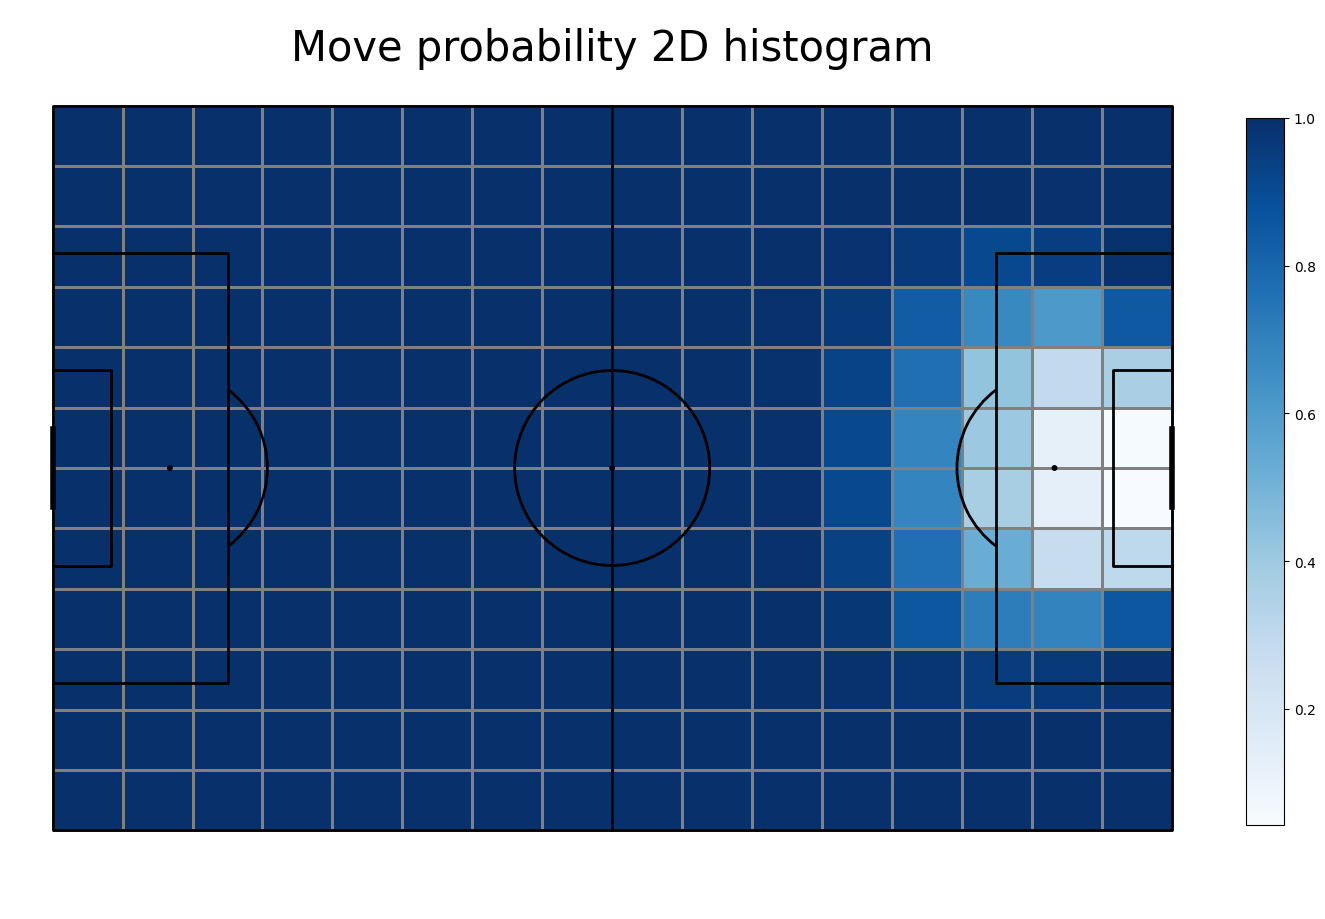

In [9]:
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
move["statistic"] = move_probability
pcm  = pitch.heatmap(move, cmap='Blues', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Move probability 2D histogram', fontsize = 30)
plt.show()

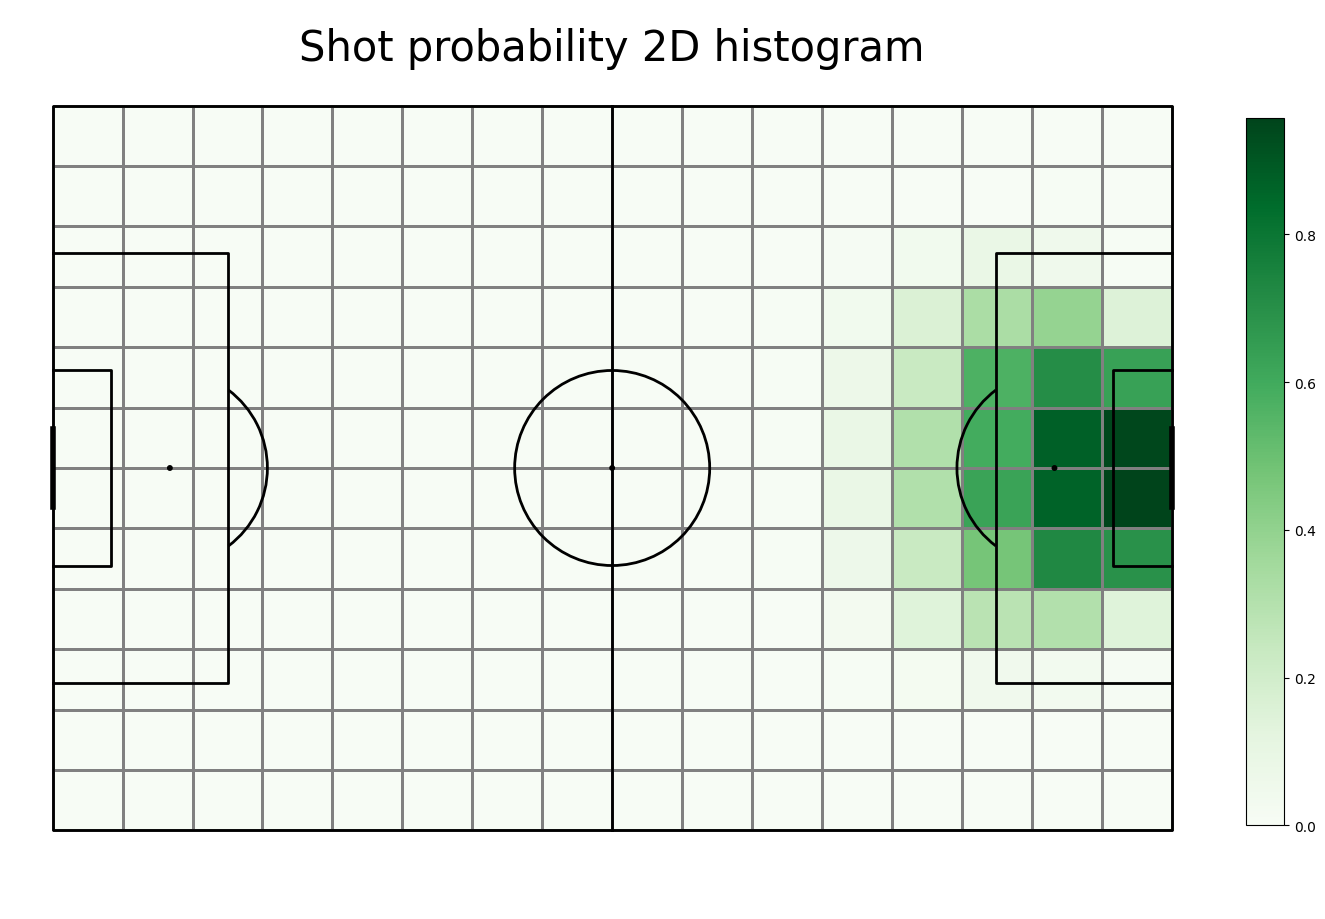

In [10]:
shot_probability = 1 - move_probability

fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
shot["statistic"] = shot_probability
pcm  = pitch.heatmap(shot, cmap='Greens', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Shot probability 2D histogram', fontsize = 30)
plt.show()

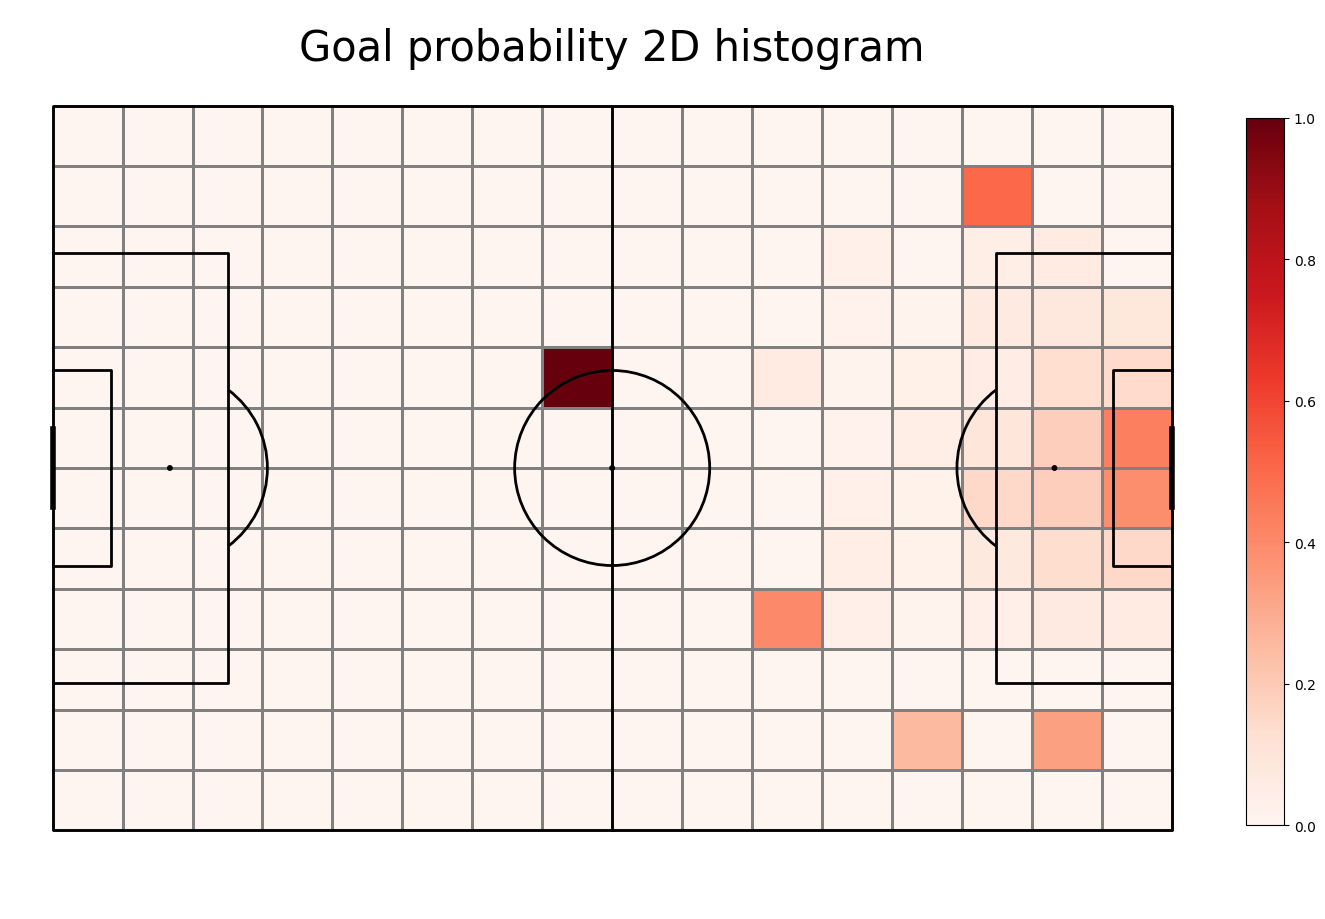

In [11]:
goal_probability = goal_count/shot_count
goal_probability[np.isnan(goal_probability)] = 0

#plotting it
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
goal["statistic"] = goal_probability
pcm  = pitch.heatmap(goal, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Goal probability 2D histogram', fontsize = 30)
plt.show()

In [12]:
#move start index - using the same function as mplsoccer, it should work
move_df["start_sector"] = move_df.apply(lambda row: tuple([i[0] for i in binned_statistic_2d(np.ravel(row.x), np.ravel(row.y),
                                                               values = "None", statistic="count",
                                                               bins=(16, 12), range=[[0, 105], [0, 68]],
                                                               expand_binnumbers=True)[3]]), axis = 1)
#move end index
move_df["end_sector"] = move_df.apply(lambda row: tuple([i[0] for i in binned_statistic_2d(np.ravel(row.end_x), np.ravel(row.end_y),
                                                               values = "None", statistic="count",
                                                               bins=(16, 12), range=[[0, 105], [0, 68]],
                                                               expand_binnumbers=True)[3]]), axis = 1)
move_df

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,nextEvent,kickedOut,x,y,end_x,end_y,start_sector,end_sector
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171,High pass,0,51.45,34.68,32.55,14.96,"(8, 7)","(5, 3)"
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172,Head pass,0,32.55,14.96,53.55,17.00,"(5, 3)","(9, 4)"
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173,Head pass,0,53.55,17.00,36.75,19.72,"(9, 4)","(6, 4)"
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174,Simple pass,0,36.75,19.72,43.05,3.40,"(6, 4)","(7, 1)"
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175,Simple pass,0,43.05,3.40,75.60,8.16,"(7, 1)","(12, 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643133,8,Simple pass,[{'id': 1801}],37725,"[{'y': 56, 'x': 57}, {'y': 63, 'x': 65}]",2500098,Pass,1633,2H,2758.973892,85,251596217,Simple pass,0,59.85,29.92,68.25,25.16,"(10, 6)","(11, 5)"
643134,8,Simple pass,[{'id': 1801}],8313,"[{'y': 63, 'x': 65}, {'y': 96, 'x': 61}]",2500098,Pass,1633,2H,2760.286946,85,251596219,Simple pass,0,68.25,25.16,64.05,2.72,"(11, 5)","(10, 1)"
643135,8,Simple pass,[{'id': 1801}],379209,"[{'y': 96, 'x': 61}, {'y': 85, 'x': 40}]",2500098,Pass,1633,2H,2763.698599,85,251596221,Touch,0,64.05,2.72,42.00,10.20,"(10, 1)","(7, 2)"
643141,8,Simple pass,[{'id': 1801}],8561,"[{'y': 70, 'x': 59}, {'y': 89, 'x': 53}]",2500098,Pass,1633,2H,2783.137836,85,251596225,High pass,0,61.95,20.40,55.65,7.48,"(10, 4)","(9, 2)"


In [13]:
#df with summed events from each index
df_count_starts = move_df.groupby(["start_sector"])["eventId"].count().reset_index()
df_count_starts.rename(columns = {'eventId':'count_starts'}, inplace=True)
df_count_starts

,start_sector,count_starts
0,"(1, 1)",168
1,"(1, 2)",224
2,"(1, 3)",134
3,"(1, 4)",162
4,"(1, 5)",136
...,...,...
187,"(16, 8)",85
188,"(16, 9)",372
189,"(16, 10)",363
190,"(16, 11)",555


In [14]:
transition_matrices = []
for i, row in df_count_starts.iterrows():
    start_sector = row['start_sector']
    count_starts = row['count_starts']
    #get all events that started in this sector
    this_sector = move_df.loc[move_df["start_sector"] == start_sector]
    df_cound_ends = this_sector.groupby(["end_sector"])["eventId"].count().reset_index()
    df_cound_ends.rename(columns = {'eventId':'count_ends'}, inplace=True)
    T_matrix = np.zeros((12, 16))
    for j, row2 in df_cound_ends.iterrows():
        end_sector = row2["end_sector"]
        value = row2["count_ends"]
        T_matrix[end_sector[1] - 1][end_sector[0] - 1] = value
    T_matrix = T_matrix / count_starts
    transition_matrices.append(T_matrix)
transition_matrices[90].shape

(12, 16)

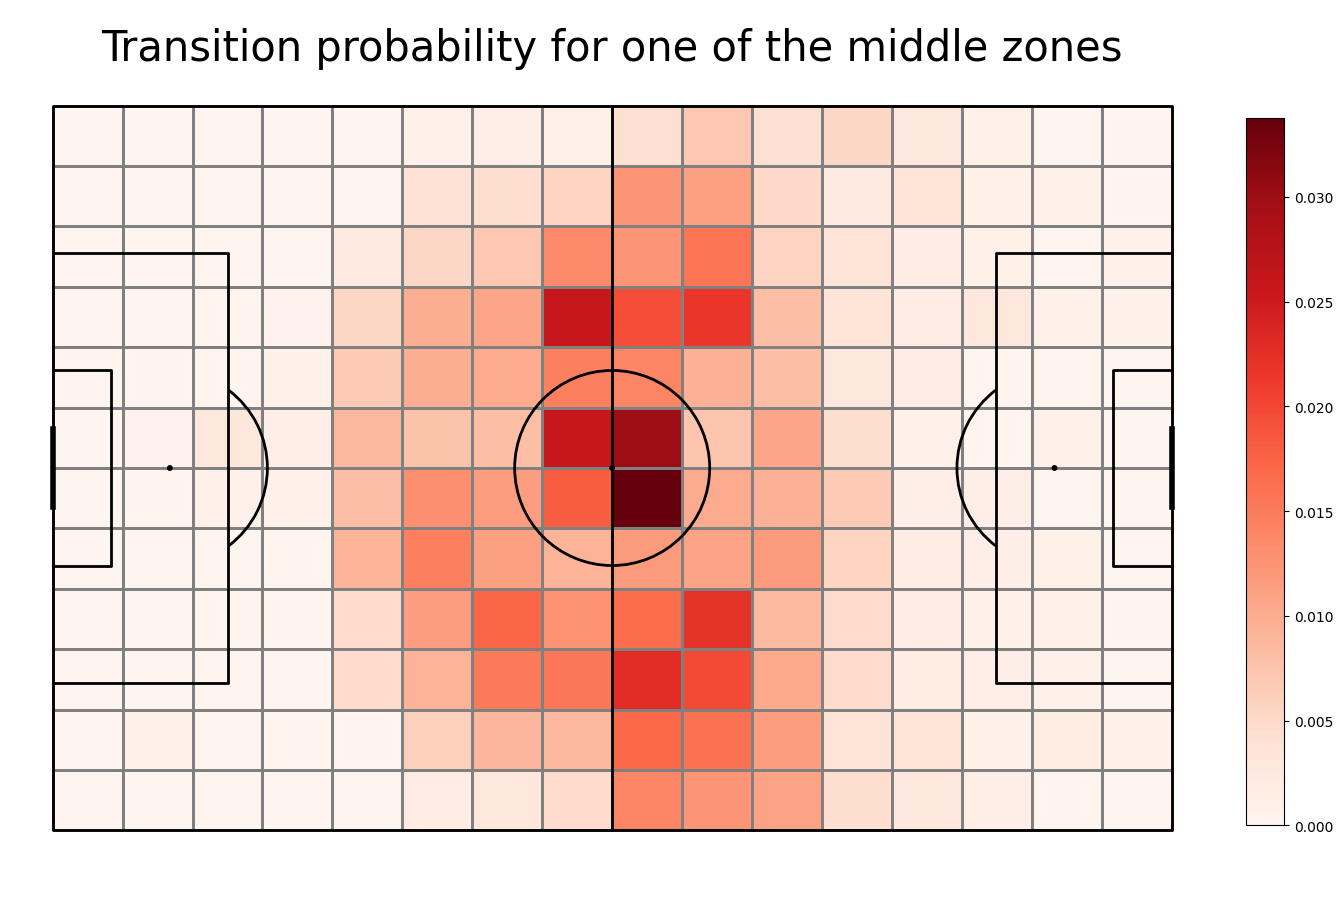

In [15]:
#let's plot it for the zone [1,1] - left down corner
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

#Change the index here to change the zone.
goal["statistic"] = transition_matrices[90]
pcm  = pitch.heatmap(goal, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Transition probability for one of the middle zones', fontsize = 30)
plt.show()

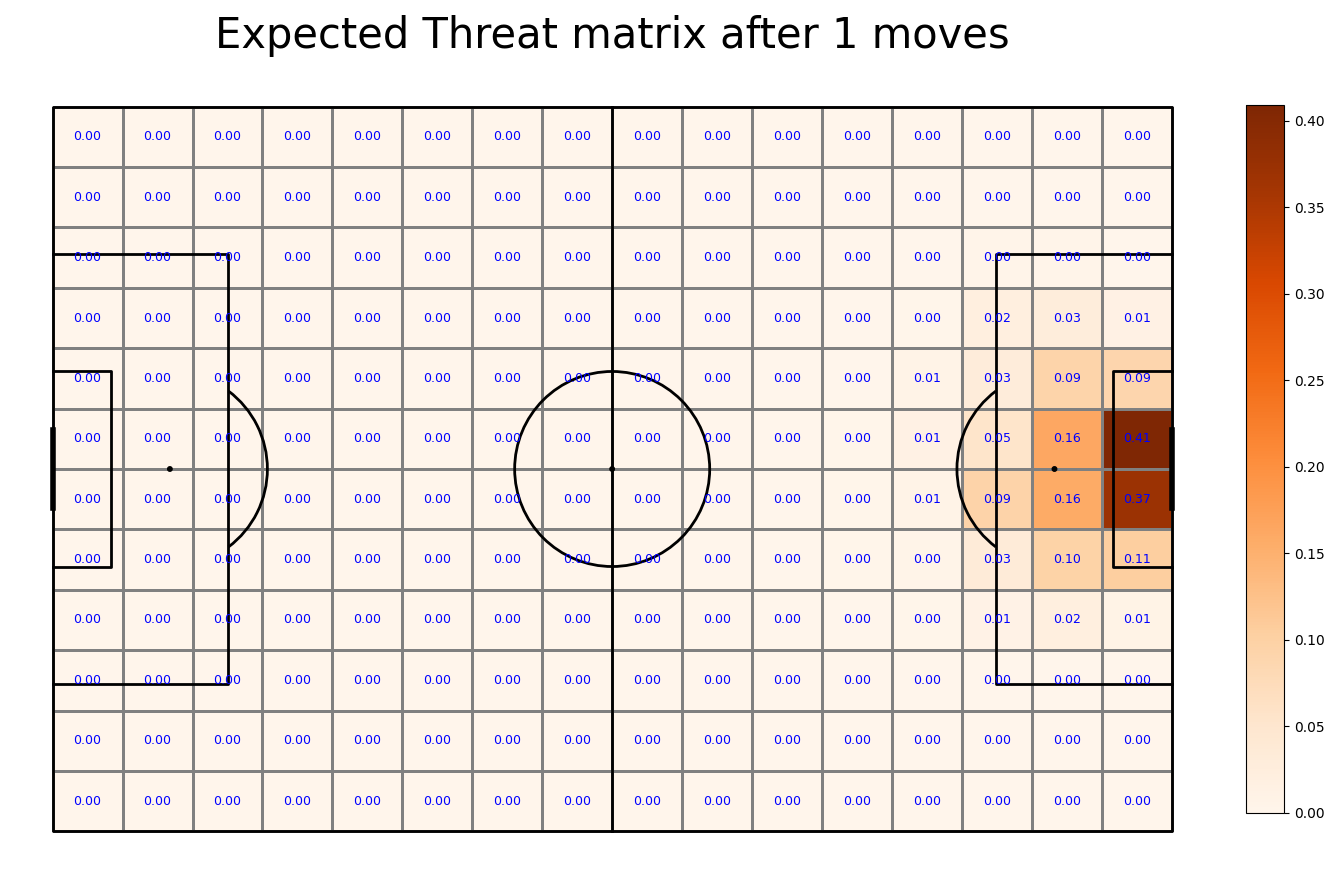

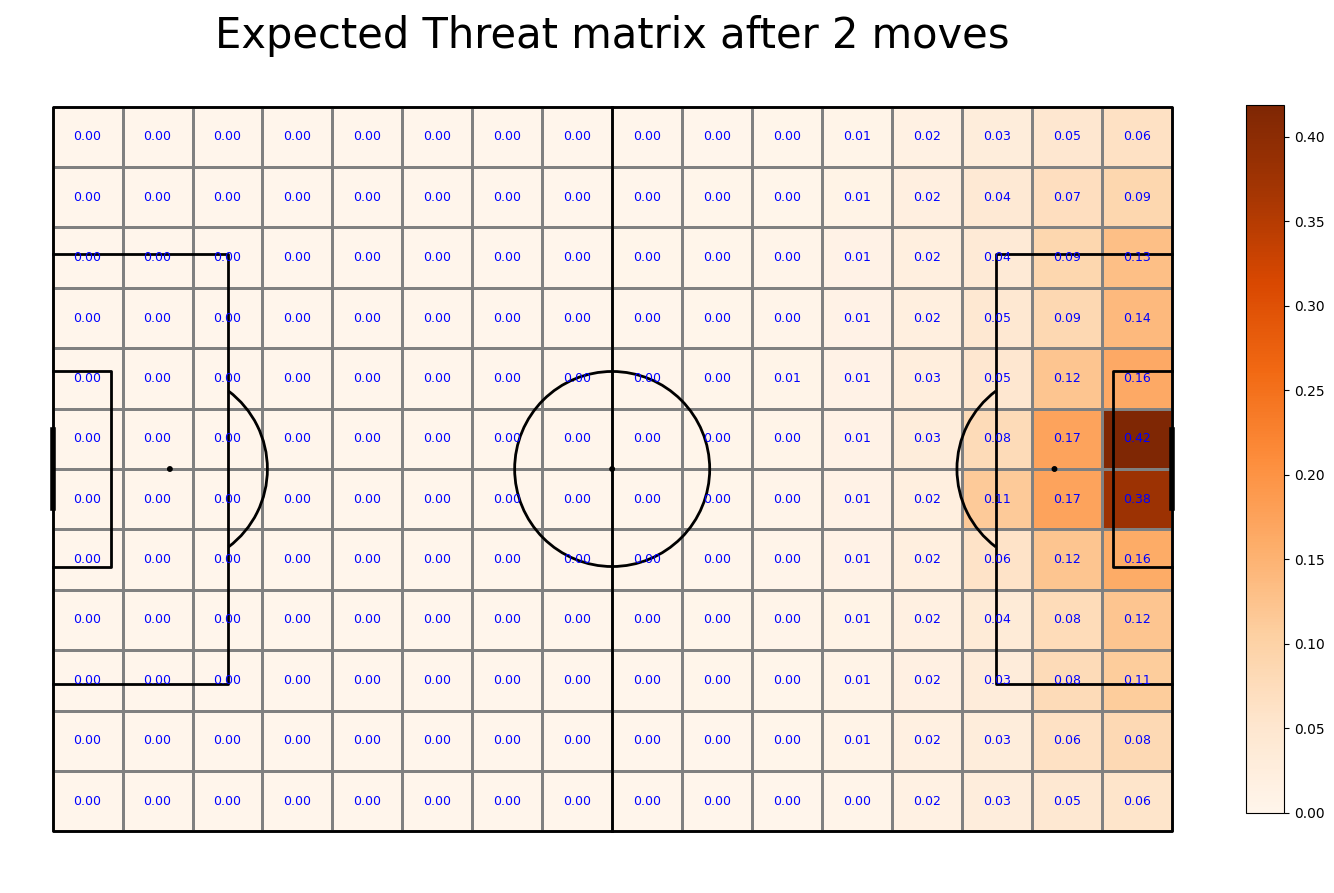

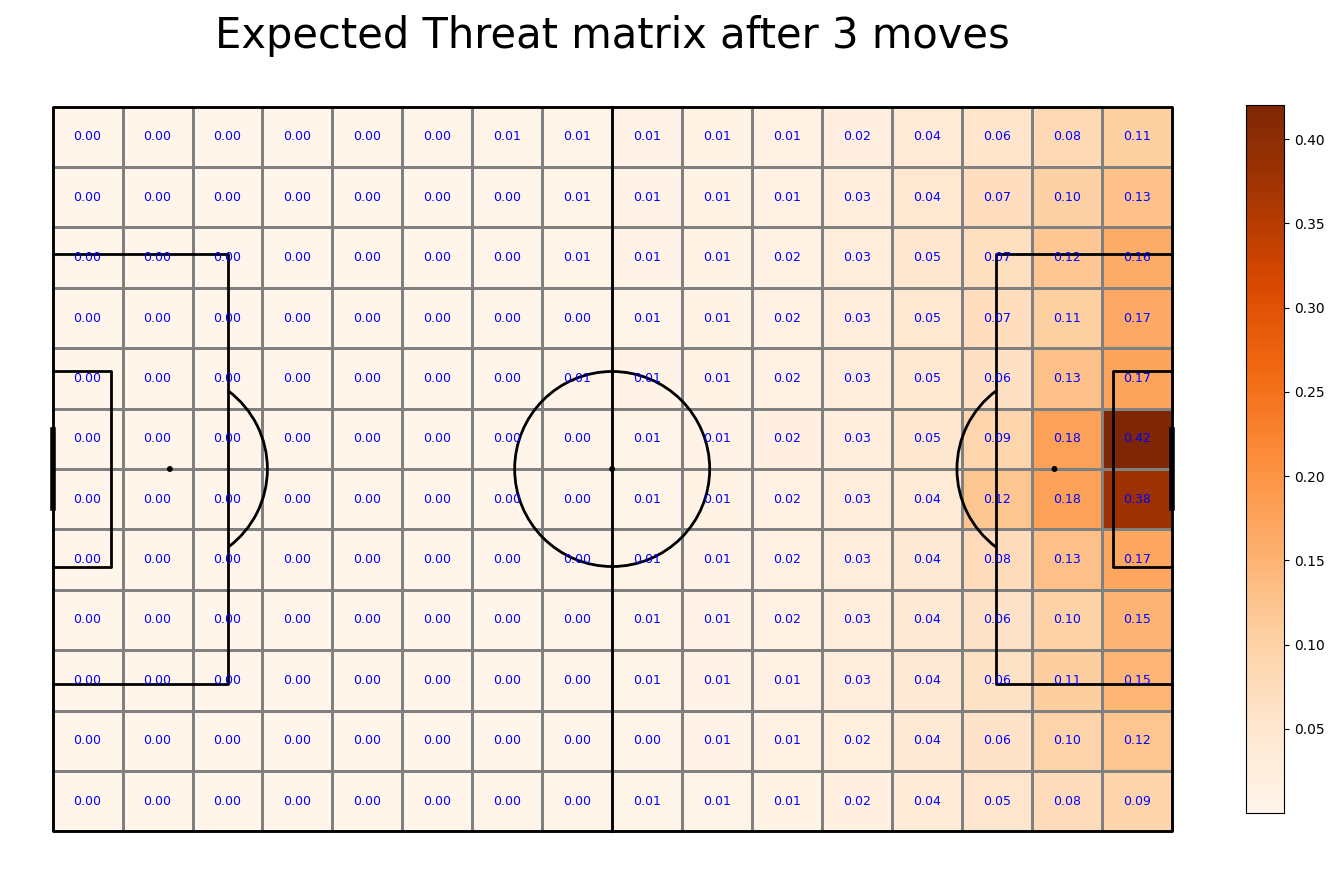

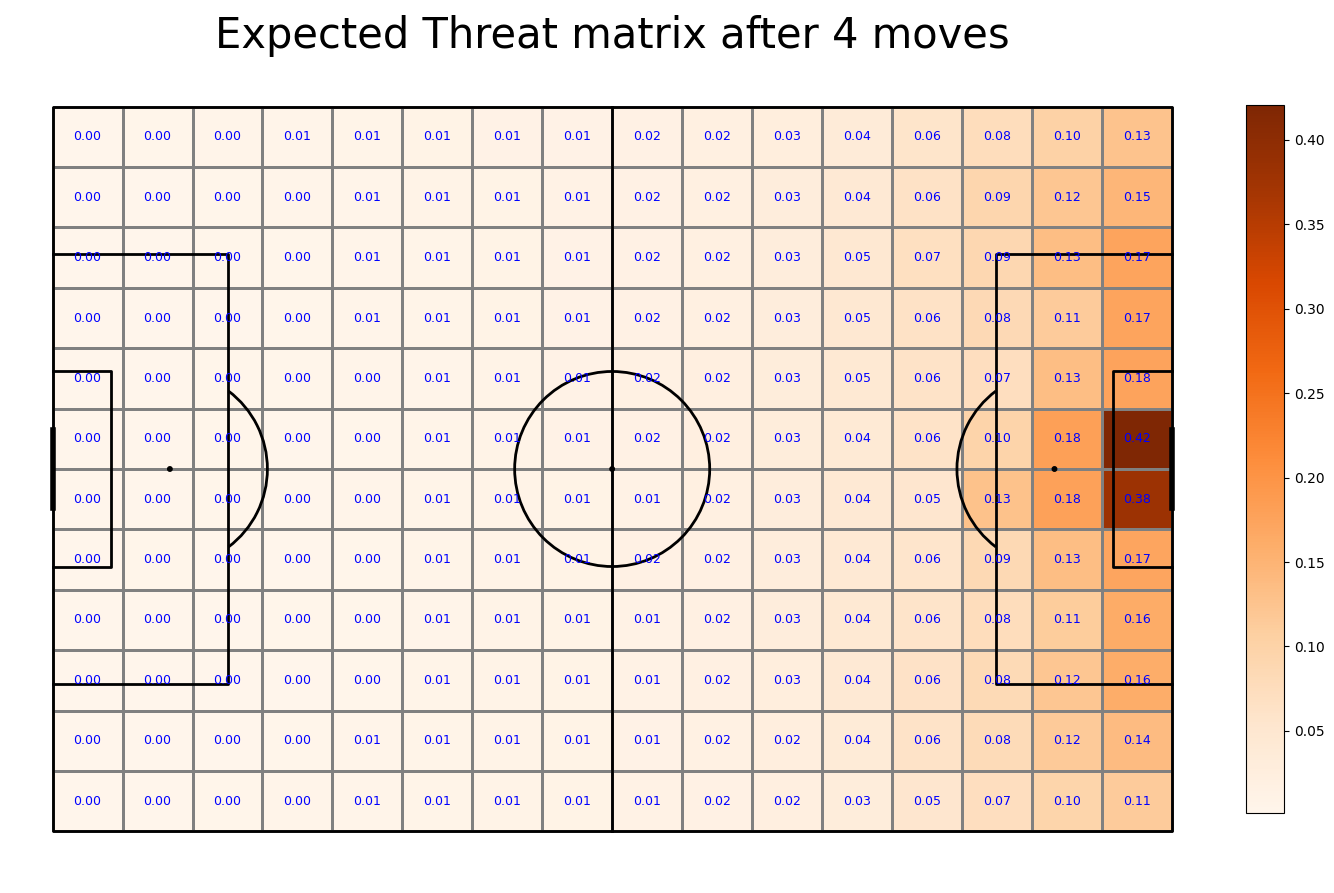

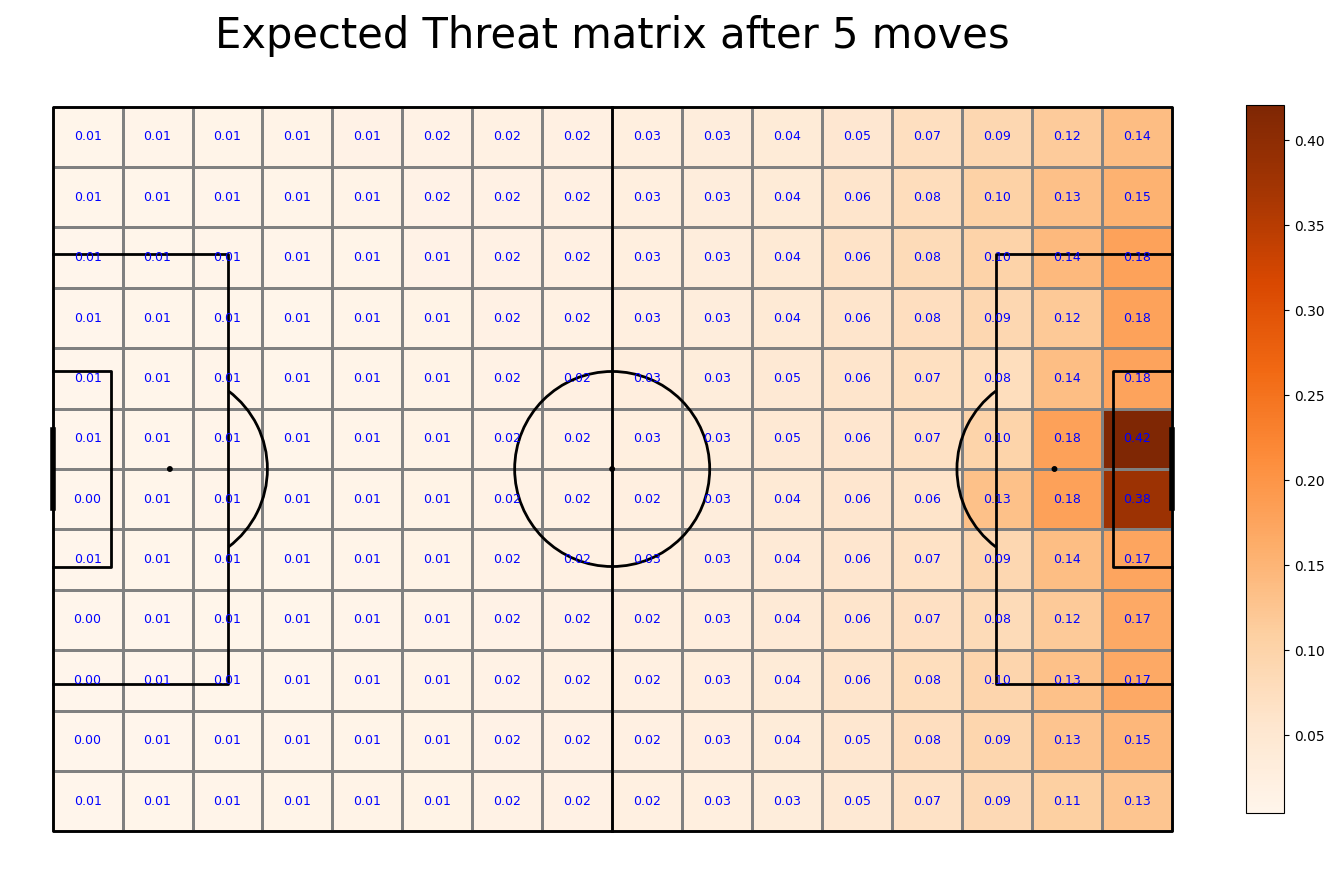

In [16]:
transition_matrices_array = np.array(transition_matrices)
xT = np.zeros((12, 16))
for i in range(5):
    shoot_expected_payoff = goal_probability*shot_probability
    move_expected_payoff = move_probability*(np.sum(np.sum(transition_matrices_array*xT, axis = 2), axis = 1).reshape(16,12).T)
    xT = shoot_expected_payoff + move_expected_payoff

    #let's plot it!
    fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.01, title_space=0, endnote_space=0)
    goal["statistic"] = xT
    pcm  = pitch.heatmap(goal, cmap='Oranges', edgecolor='grey', ax=ax['pitch'])
    labels = pitch.label_heatmap(goal, color='blue', fontsize=9,
                             ax=ax['pitch'], ha='center', va='center', str_format="{0:,.2f}", zorder = 3)
    #legend to our plot
    ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
    cbar = plt.colorbar(pcm, cax=ax_cbar)
    txt = 'Expected Threat matrix after ' +  str(i+1) + ' moves'
    fig.suptitle(txt, fontsize = 30)
    plt.show()

In [17]:
#only successful
successful_moves = move_df.loc[move_df.apply(lambda x:{'id':1801} in x.tags, axis = 1)]
#calculatexT
successful_moves["xT_added"] = successful_moves.apply(lambda row: xT[row.end_sector[1] - 1][row.end_sector[0] - 1]
                                                      - xT[row.start_sector[1] - 1][row.start_sector[0] - 1], axis = 1)
#only progressive
value_adding_actions = successful_moves.loc[successful_moves["xT_added"] > 0]
value_adding_actions

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,...,id,nextEvent,kickedOut,x,y,end_x,end_y,start_sector,end_sector,xT_added
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,...,177959172,Head pass,0,32.55,14.96,53.55,17.00,"(5, 3)","(9, 4)",0.016113
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,...,177959174,Simple pass,0,36.75,19.72,43.05,3.40,"(6, 4)","(7, 1)",0.006287
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,...,177959175,Simple pass,0,43.05,3.40,75.60,8.16,"(7, 1)","(12, 2)",0.038022
6,8,Head pass,[{'id': 1801}],8653,"[{'y': 25, 'x': 23}, {'y': 15, 'x': 39}]",2499719,Pass,1631,1H,13.961228,...,177959186,Air duel,0,24.15,51.00,40.95,57.80,"(4, 10)","(7, 11)",0.008389
11,8,High pass,[{'id': 1801}],14869,"[{'y': 45, 'x': 45}, {'y': 54, 'x': 71}]",2499719,Pass,1609,1H,20.426527,...,177959180,Air duel,0,47.25,37.40,74.55,31.28,"(8, 7)","(12, 6)",0.035818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643129,8,Simple pass,[{'id': 1801}],37725,"[{'y': 51, 'x': 55}, {'y': 67, 'x': 60}]",2500098,Pass,1633,2H,2750.561883,...,251596212,Simple pass,0,57.75,33.32,63.00,22.44,"(9, 6)","(10, 4)",0.007482
643130,8,Simple pass,[{'id': 1801}],20620,"[{'y': 67, 'x': 60}, {'y': 77, 'x': 66}]",2500098,Pass,1633,2H,2753.232101,...,251596214,Simple pass,0,63.00,22.44,69.30,15.64,"(10, 4)","(11, 3)",0.010771
643132,8,Simple pass,[{'id': 1801}],8561,"[{'y': 80, 'x': 60}, {'y': 56, 'x': 57}]",2500098,Pass,1633,2H,2758.481252,...,251596216,Simple pass,0,63.00,13.60,59.85,29.92,"(10, 3)","(10, 6)",0.001999
643133,8,Simple pass,[{'id': 1801}],37725,"[{'y': 56, 'x': 57}, {'y': 63, 'x': 65}]",2500098,Pass,1633,2H,2758.973892,...,251596217,Simple pass,0,59.85,29.92,68.25,25.16,"(10, 6)","(11, 5)",0.010568


In [18]:
#group by player
xT_by_player = value_adding_actions.groupby(["playerId"])["xT_added"].sum().reset_index()
#merging player name
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/players.json')
player_df = pd.read_json(path, encoding='unicode-escape')
player_df.rename(columns = {'wyId':'playerId'}, inplace=True)
player_df["role"] = player_df.apply(lambda x: x.role["name"], axis = 1)
to_merge = player_df[['playerId', 'shortName', 'role']]

summary = xT_by_player.merge(to_merge, how = "left", on = ["playerId"])
summary

,playerId,xT_added,shortName,role
0,36,9.684073,T. Alderweireld,Defender
1,38,2.226775,D. Blind,Defender
2,48,19.732019,J. Vertonghen,Defender
3,54,25.465235,C. Eriksen,Midfielder
4,56,0.896195,D. Klaassen,Midfielder
...,...,...,...,...
502,447812,1.531894,T. Edwards,Defender
503,448708,0.099935,H. Barnes,Midfielder
504,450826,0.210212,C. Hudson-Odoi,Midfielder
505,486252,2.056922,A. Wan-Bissaka,Defender


In [19]:
path = pathlib.Path('/home/ganesh/soccermatics/data/minutes_played_per_game_England.json')
with open(path) as f:
    minutes_per_game = json.load(f)
#filtering over 400 per game
minutes_per_game = pd.DataFrame(minutes_per_game)
minutes = minutes_per_game.groupby(["playerId"]).minutesPlayed.sum().reset_index()
summary = minutes.merge(summary, how = "left", on = ["playerId"])
summary = summary.fillna(0)
summary = summary.loc[summary["minutesPlayed"] > 400]
#calculating per 90
summary["xT_per_90"] = summary["xT_added"]*90/summary["minutesPlayed"]
summary

,playerId,minutesPlayed,xT_added,shortName,role,xT_per_90
0,36,1238,9.684073,T. Alderweireld,Defender,0.704012
2,48,3343,19.732019,J. Vertonghen,Defender,0.531224
3,54,3348,25.465235,C. Eriksen,Midfielder,0.684549
5,74,1514,8.096305,R. Klavan,Defender,0.481286
6,93,2942,8.366193,J. Guðmunds­son,Midfielder,0.255934
...,...,...,...,...,...,...
491,397178,1904,5.345465,M. Rashford,Forward,0.252674
500,419784,405,1.380595,H. Choudhury,Midfielder,0.306799
502,434159,561,2.077225,S. Field,Midfielder,0.333245
508,447812,499,1.531894,T. Edwards,Defender,0.276294


In [20]:
#adjusting for possesion
path = pathlib.Path('/home/ganesh/soccermatics/data/player_possesion_England.json')
with open(path) as f:
    percentage_df = json.load(f)
percentage_df = pd.DataFrame(percentage_df)
#merge it
summary = summary.merge(percentage_df, how = "left", on = ["playerId"])
summary["xT_adjusted_per_90"] = (summary["xT_added"]/summary["possesion"])*90/summary["minutesPlayed"]
summary

,playerId,minutesPlayed,xT_added,shortName,role,xT_per_90,possesion,xT_adjusted_per_90
0,36,1238,9.684073,T. Alderweireld,Defender,0.704012,0.597434,1.178392
1,48,3343,19.732019,J. Vertonghen,Defender,0.531224,0.597295,0.889382
2,54,3348,25.465235,C. Eriksen,Midfielder,0.684549,0.606674,1.128365
3,74,1514,8.096305,R. Klavan,Defender,0.481286,0.592251,0.812639
4,93,2942,8.366193,J. Guðmunds­son,Midfielder,0.255934,0.438288,0.583941
...,...,...,...,...,...,...,...,...
392,397178,1904,5.345465,M. Rashford,Forward,0.252674,0.552620,0.457230
393,419784,405,1.380595,H. Choudhury,Midfielder,0.306799,0.520446,0.589492
394,434159,561,2.077225,S. Field,Midfielder,0.333245,0.402257,0.828437
395,447812,499,1.531894,T. Edwards,Defender,0.276294,0.420026,0.657802


In [21]:
summary[['shortName', 'xT_adjusted_per_90']].sort_values(by='xT_adjusted_per_90', ascending=False).head(10)

,shortName,xT_adjusted_per_90
27,Fàbregas,1.954186
271,K. De Bruyne,1.546140
68,P. Pogba,1.517259
22,M. Özil,1.511402
78,J. Shelvey,1.453346
39,Philippe Coutinho,1.445208
117,David Silva,1.417882
77,J. Henderson,1.398503
118,J. Milner,1.352086
125,C. Brunt,1.315329
